# 01 - Exploración: Mantenimiento Predictivo (NASA Turbofan)
Análisis exploratorio de los datos enriquecidos con RUL.

In [3]:
!pip install matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 325.1 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 326.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 448.9 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.3 MB 2.0 MB/s eta 0:00:05
   ---------------------------------------- 0.1/9.3 MB 1.2 MB/s eta 0:00:08
    ---------------------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/curated/sample_FD001_train.parquet')
df.head()

,id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,rul,label
0,1,1,0.0024,0.0003,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8134.65,8.4195,0.03,392.00,2388.0,0.02,0.0,0.0,3,1
1,1,2,0.0024,0.0003,100.0,518.72,642.15,1591.82,1402.31,14.64,...,8133.12,8.4318,0.03,391.50,2388.0,0.02,0.0,0.0,2,1
2,1,3,0.0025,0.0003,100.0,518.81,642.35,1593.45,1404.12,14.66,...,8132.44,8.4402,0.03,391.00,2388.0,0.02,0.0,0.0,1,1
3,1,4,0.0025,0.0004,100.0,518.95,642.71,1595.16,1406.03,14.68,...,8131.77,8.4521,0.03,390.55,2388.0,0.02,0.0,0.0,0,1
4,2,1,0.0031,0.0002,100.0,517.90,642.20,1590.10,1399.80,14.59,...,8135.20,8.4051,0.03,392.30,2388.0,0.02,0.0,0.0,2,1


In [5]:
print('Motores:', df['id'].nunique())
print('Filas:', len(df))
print('Distribución de label (1 = fallo inminente):')
print(df['label'].value_counts())

Motores: 2
Filas: 7
Distribución de label (1 = fallo inminente):
label
1    7
Name: count, dtype: int64


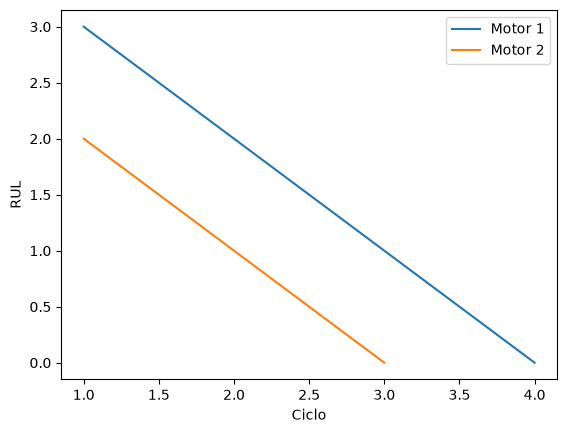

In [6]:
for mid in df['id'].unique()[:2]:
    sub = df[df['id'] == mid]
    plt.plot(sub['cycle'], sub['rul'], label=f'Motor {mid}')
plt.xlabel('Ciclo'); plt.ylabel('RUL'); plt.legend(); plt.show()